# NB03 — Phase 1A Pilot Atlas + Control Validation

**Project**: Gene Function Ecological Agora — Innovation Atlas Across the Bacterial Tree  
**Phase**: 1A — Pilot atlas (per-clade × UniRef scoring) and control validation  
**Purpose**: Apply the multi-rank null models from NB02 to compute producer z-scores per (clade, UniRef) at each rank. Validate negative and positive controls. Reproduce Alm 2006 TCS HK paralog-expansion at pilot scale. Produce the diagnostic data NB04 uses for the Phase 1A → 1B gate decision.

## Inputs

- `data/p1a_pilot_species.tsv` — species rank scaffold
- `data/p1a_pilot_uniref50.tsv` — pilot UniRef50s with control_class (incl. natural_expansion)
- `data/p1a_pilot_extract.parquet` — (species, UniRef50) presence/paralog rows
- `data/p1a_null_producer_lookup.parquet` — per-(rank, clade, prevalence_bin) cohort moments
- `data/p1a_null_consumer_lookup.parquet` — per-(rank, UniRef50) consumer z-scores (pre-computed in NB02)
- `data/p1a_uniref_prevalence_bin.tsv` — per-(rank, UniRef50) prevalence bin assignment

## Outputs

- `data/p1a_pilot_scores.parquet` — long-form (rank, clade_id, uniref50_id, producer_z, consumer_z, control_class)
- `data/p1a_control_validation.tsv` — per-(rank, control_class) score summary
- `data/p1a_alm_2006_pilot_backtest.tsv` — TCS HK reproduction
- `data/p1a_pilot_atlas_diagnostics.json` — atlas-level diagnostics
- `figures/p1a_scores_by_class_per_rank.png` — violin plots of producer and consumer z by control class per rank
- `figures/p1a_producer_consumer_per_rank.png` — Producer × Participation scatter per rank, colored by control class

## Methodology

### Producer z-score per (clade, UniRef)

For each rank R:
1. Build clade × UniRef paralog matrix (`max` paralog count across species within clade)
2. For each (clade C, UniRef U) where U is present in C:
   - Look up cohort moments at (R, C, prevalence_bin(R, U))
   - producer_z = (paralog(C, U) - cohort_mean) / cohort_std
3. Score is undefined when cohort_size < 5 (recorded as NaN)

### Consumer z-score

Pre-computed in NB02. Per-(rank, UniRef) parent-phylum dispersion z-score relative to permutation null.

### Control validation criteria

- **Negative controls (ribosomal / tRNA-synth / RNAP)**: producer mean within ±1σ of 0; consumer mean ≤ 0 (clumped, vertical inheritance) at each rank
- **Positive control AMR**: consumer mean > 0 at some rank (HGT acquisition signal)
- **Positive control TCS HK + Alm 2006 reproduction**: producer mean > 0 at family or order rank (paralog expansion — the Alm 2006 finding) with at least one significant individual UniRef
- **Natural expansion**: producer mean > 0 at some rank (we sampled these for paralog signal — methodology sanity check)

## Setup

In [1]:
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/home/aparkin/BERIL-research-observatory/projects/gene_function_ecological_agora")
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"

RANKS = ["genus", "family", "order", "class", "phylum"]
PARENT_RANK = "phylum"  # consumer null is parent-phylum dispersion; phylum rank itself has no consumer score

diagnostics = {
    "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "ranks": RANKS,
    "parent_rank": PARENT_RANK,
}

## Stage 1 — Load pilot data + null lookups

In [2]:
species_df = pd.read_csv(DATA_DIR / "p1a_pilot_species.tsv", sep="\t")
uniref_df = pd.read_csv(DATA_DIR / "p1a_pilot_uniref50.tsv", sep="\t")
extract_df = pd.read_parquet(DATA_DIR / "p1a_pilot_extract.parquet")
producer_lookup = pd.read_parquet(DATA_DIR / "p1a_null_producer_lookup.parquet")
consumer_lookup = pd.read_parquet(DATA_DIR / "p1a_null_consumer_lookup.parquet")
prev_bin_lookup = pd.read_csv(DATA_DIR / "p1a_uniref_prevalence_bin.tsv", sep="\t")

# Apply paralog fallback (option a)
extract_df["paralog_count"] = np.where(
    extract_df["n_uniref90_present"] >= 1,
    extract_df["n_uniref90_present"],
    extract_df["n_gene_clusters"],
).astype(int)

print(f"Species:           {species_df.shape}")
print(f"UniRef:            {uniref_df.shape}")
print(f"Extract:           {extract_df.shape}")
print(f"Producer lookup:   {producer_lookup.shape}  ranks: {producer_lookup['rank'].unique().tolist()}")
print(f"Consumer lookup:   {consumer_lookup.shape}  ranks: {consumer_lookup['rank'].unique().tolist()}")
print(f"Prev-bin lookup:   {prev_bin_lookup.shape}  ranks: {prev_bin_lookup['rank'].unique().tolist()}")

Species:           (1000, 22)
UniRef:            (1200, 15)
Extract:           (6638, 6)
Producer lookup:   (876, 9)  ranks: ['genus', 'family', 'order', 'class', 'phylum']
Consumer lookup:   (4800, 7)  ranks: ['genus', 'family', 'order', 'class']
Prev-bin lookup:   (6000, 4)  ranks: ['genus', 'family', 'order', 'class', 'phylum']


## Stage 2 — Aggregate paralog matrices to each rank

In [3]:
# Build species → clade label per rank (matching NB02's logic)
species_id_to_idx = {s: i for i, s in enumerate(species_df["gtdb_species_clade_id"])}
uniref_id_to_idx = {u: i for i, u in enumerate(uniref_df["uniref50_id"])}
N_SPECIES = len(species_id_to_idx)
N_UREFS = len(uniref_id_to_idx)

# Species × UniRef paralog matrix
M_par = np.zeros((N_SPECIES, N_UREFS), dtype=np.int32)
M_pres = np.zeros((N_SPECIES, N_UREFS), dtype=np.int8)
for _, row in extract_df.iterrows():
    s_id = row["gtdb_species_clade_id"]; u_id = row["uniref50_id"]
    if s_id in species_id_to_idx and u_id in uniref_id_to_idx:
        i = species_id_to_idx[s_id]; j = uniref_id_to_idx[u_id]
        M_par[i, j] = row["paralog_count"]
        M_pres[i, j] = 1

rank_clade_data = {}
for rank in RANKS:
    labels = species_df.set_index("gtdb_species_clade_id").reindex(
        species_df["gtdb_species_clade_id"]
    )[rank].fillna("unknown").tolist()
    label_arr = np.array(labels)
    unique_clades = sorted(set(label_arr) - {"unknown"})
    K = len(unique_clades)
    clade_to_idx = {c: i for i, c in enumerate(unique_clades)}

    M_clade_par = np.zeros((K, N_UREFS), dtype=np.int32)
    M_clade_pres = np.zeros((K, N_UREFS), dtype=np.int8)
    for sp_i in range(N_SPECIES):
        clade = label_arr[sp_i]
        if clade == "unknown":
            continue
        ki = clade_to_idx[clade]
        np.maximum(M_clade_par[ki, :], M_par[sp_i, :], out=M_clade_par[ki, :])
        M_clade_pres[ki, :] |= M_pres[sp_i, :]

    rank_clade_data[rank] = {
        "clade_ids": unique_clades,
        "clade_to_idx": clade_to_idx,
        "M_par": M_clade_par,
        "M_pres": M_clade_pres,
    }
    print(f"  {rank:8s}: {K:5d} clades  {int(M_clade_pres.sum()):6d} presences")

  genus   :   770 clades    5148 presences
  family  :   457 clades    3722 presences
  order   :   287 clades    2970 presences
  class   :   164 clades    2247 presences
  phylum  :   110 clades    2100 presences


## Stage 3 — Compute producer z-scores per (rank, clade, UniRef)

In [4]:
score_rows = []

for rank in RANKS:
    rdata = rank_clade_data[rank]
    K = len(rdata["clade_ids"])
    if K == 0:
        continue
    M_par_r = rdata["M_par"]
    M_pres_r = rdata["M_pres"]
    clade_to_idx = rdata["clade_to_idx"]

    # Build (clade, prev_bin) → (cohort_mean, cohort_std) lookup for this rank
    rank_prod = producer_lookup[producer_lookup["rank"] == rank].copy()
    prod_lookup_dict = {
        (row["clade_id"], int(row["prevalence_bin"])): (row["cohort_mean_paralog"], row["cohort_std_paralog"], int(row["cohort_size"]))
        for _, row in rank_prod.iterrows()
    }

    # UniRef → prevalence_bin at this rank
    rank_pb = prev_bin_lookup[prev_bin_lookup["rank"] == rank].set_index("uniref50_id")["prevalence_bin"].to_dict()

    # Compute producer_z per (clade, uniref) where present and lookup exists
    for c_i, clade_id in enumerate(rdata["clade_ids"]):
        present_urefs = np.where(M_pres_r[c_i, :] == 1)[0]
        for u_j in present_urefs:
            uref_id = uniref_df["uniref50_id"].iloc[u_j]
            pb = rank_pb.get(uref_id)
            if pb is None:
                continue
            key = (clade_id, int(pb))
            if key not in prod_lookup_dict:
                continue
            mean_, std_, csize_ = prod_lookup_dict[key]
            paralog = int(M_par_r[c_i, u_j])
            producer_z = (paralog - mean_) / std_ if std_ > 0 else 0.0
            score_rows.append({
                "rank": rank,
                "clade_id": clade_id,
                "uniref50_id": uref_id,
                "paralog_count": paralog,
                "prevalence_bin": int(pb),
                "cohort_mean_paralog": float(mean_),
                "cohort_std_paralog": float(std_),
                "cohort_size": csize_,
                "producer_z": float(producer_z),
            })

scores_df = pd.DataFrame(score_rows)
print(f"Producer scores computed: {len(scores_df):,} (clade, UniRef) rows")
diagnostics["n_producer_scores"] = int(len(scores_df))
print(f"\nProducer z distribution per rank:")
print(scores_df.groupby("rank")["producer_z"].describe())

Producer scores computed: 9,201 (clade, UniRef) rows

Producer z distribution per rank:
         count          mean       std       min       25%       50%  75%  \
rank                                                                        
class   1705.0  2.708814e-17  0.829687 -0.724846 -0.418453 -0.316228  0.0   
family  1851.0  1.919348e-18  0.761222 -1.632993 -0.428174  0.000000  0.0   
genus   2061.0 -1.400572e-18  0.675508 -1.095445 -0.387174  0.000000  0.0   
order   1822.0 -1.316181e-17  0.811098 -0.866667 -0.408248 -0.250000  0.0   
phylum  1762.0  1.310592e-17  0.828235 -0.775959 -0.404536 -0.296646  0.0   

             max  
rank              
class   6.144803  
family  4.547640  
genus   3.750000  
order   5.361904  
phylum  6.450474  


## Stage 4 — Join with consumer scores + control class

In [5]:
# Join consumer z (pre-computed in NB02) onto the producer-scored rows.
# Consumer is per-(rank, UniRef); broadcast over clades within rank.
consumer_compact = consumer_lookup[["rank", "uniref50_id", "n_clades_with", "obs_parent_dispersion", "consumer_z"]]
scores_df = scores_df.merge(consumer_compact, on=["rank", "uniref50_id"], how="left")

# Join control_class
scores_df = scores_df.merge(
    uniref_df[["uniref50_id", "control_class", "dominant_cog_category", "dominant_ipr_desc"]],
    on="uniref50_id", how="left",
)

# Filter consumer to informative subset (n_clades_with ≥ 3) for headline statistics
scores_df["consumer_z_informative"] = np.where(
    scores_df["n_clades_with"].fillna(0) >= 3, scores_df["consumer_z"], np.nan
)

print(f"Final scores table: {scores_df.shape}")
print(f"\nProducer scores per rank × class (count):")
print(scores_df.groupby(["rank", "control_class"]).size().unstack(fill_value=0))

Final scores table: (9201, 16)

Producer scores per rank × class (count):
control_class  natural_expansion  neg_ribosomal  neg_rnap_core  \
rank                                                             
class                        482            285            259   
family                       802            237            180   
genus                        975            276            237   
order                        654            258            211   
phylum                       457            315            284   

control_class  neg_trna_synth  pos_amr  pos_tcs_hk  
rank                                                
class                     222      283         174  
family                    192      316         124  
genus                     199      301          73  
order                     208      334         157  
phylum                    248      272         186  


## Stage 5 — Control validation

Compute mean ± 95% CI per (rank, control_class) for both producer_z and consumer_z (informative subset). Apply criteria:

- **Negative controls pass** if 95% CI contains 0 for producer AND 95% CI ≤ 0 for consumer
- **AMR positive control passes** if consumer 95% CI > 0 at some rank
- **TCS HK positive control passes** if producer 95% CI > 0 at family OR order rank
- **Natural expansion** sanity check: producer 95% CI > 0 at some rank (we picked these for expansion)

In [6]:
from scipy import stats

def ci95(values):
    """Return (mean, ci_low, ci_high, n) for a 95% CI of the mean. Returns NaNs if n<3."""
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    n = len(arr)
    if n < 3:
        return (np.nan, np.nan, np.nan, n)
    mean = arr.mean()
    sem = arr.std(ddof=1) / np.sqrt(n)
    ci = sem * stats.t.ppf(0.975, n - 1)
    return (mean, mean - ci, mean + ci, n)

validation_rows = []
for (rank, cls), sub in scores_df.groupby(["rank", "control_class"]):
    pmean, pl, ph, pn = ci95(sub["producer_z"].values)
    cmean, cl, ch, cn = ci95(sub["consumer_z_informative"].values)
    validation_rows.append({
        "rank": rank, "control_class": cls,
        "n_producer": pn, "producer_mean": pmean, "producer_ci_low": pl, "producer_ci_high": ph,
        "n_consumer": cn, "consumer_mean": cmean, "consumer_ci_low": cl, "consumer_ci_high": ch,
    })
validation_df = pd.DataFrame(validation_rows)

# Apply pass/fail criteria
def negative_control_pass(row):
    if row["n_producer"] < 3 or row["n_consumer"] < 3:
        return "insufficient_n"
    producer_zero_in_ci = (row["producer_ci_low"] <= 0) and (row["producer_ci_high"] >= 0)
    consumer_clumped = row["consumer_ci_high"] <= 0
    return "PASS" if (producer_zero_in_ci and consumer_clumped) else "FAIL"

def positive_amr_pass(row):
    if row["n_consumer"] < 3:
        return "insufficient_n"
    return "PASS" if row["consumer_ci_low"] > 0 else "FAIL_OR_VERTICAL"

def positive_tcs_pass(row):
    if row["n_producer"] < 3:
        return "insufficient_n"
    return "PASS" if row["producer_ci_low"] > 0 else "FAIL"

def natural_expansion_check(row):
    if row["n_producer"] < 3:
        return "insufficient_n"
    return "PASS" if row["producer_ci_low"] > 0 else "WEAK"

verdict_rows = []
for _, row in validation_df.iterrows():
    cls = row["control_class"]
    if cls in ("neg_ribosomal", "neg_trna_synth", "neg_rnap_core"):
        v = negative_control_pass(row)
    elif cls == "pos_amr":
        v = positive_amr_pass(row)
    elif cls == "pos_tcs_hk":
        v = positive_tcs_pass(row)
    elif cls == "natural_expansion":
        v = natural_expansion_check(row)
    else:
        v = "n/a"
    verdict_rows.append(v)
validation_df["verdict"] = verdict_rows

print("Control validation per rank:")
print(validation_df.to_string(index=False, float_format="%.3f"))
diagnostics["control_validation"] = validation_df.to_dict(orient="records")

Control validation per rank:
  rank     control_class  n_producer  producer_mean  producer_ci_low  producer_ci_high  n_consumer  consumer_mean  consumer_ci_low  consumer_ci_high          verdict
 class natural_expansion         482          0.498            0.384             0.612         318         -1.566           -1.815            -1.316             PASS
 class     neg_ribosomal         285         -0.159           -0.202            -0.116         138         -0.034           -0.195             0.128             FAIL
 class     neg_rnap_core         259         -0.229           -0.256            -0.201         132         -1.076           -1.396            -0.757             FAIL
 class    neg_trna_synth         222         -0.213           -0.259            -0.166          67         -0.996           -1.403            -0.589             FAIL
 class           pos_amr         283         -0.170           -0.243            -0.098          87         -1.668           -2.154           

## Stage 6 — Alm 2006 TCS HK paralog-expansion reproduction at pilot scale

Alm 2006 found that two-component-system histidine kinases show lineage-specific paralog expansion. At pilot scale, we should see TCS HK UniRefs with positive producer z in some clades, especially at family/order rank where the paralog signal accumulates.

In [7]:
tcs_scores = scores_df[scores_df["control_class"] == "pos_tcs_hk"].copy()

alm_rows = []
for rank in RANKS:
    sub = tcs_scores[tcs_scores["rank"] == rank]
    n_total = len(sub)
    if n_total == 0:
        continue
    n_pos_z = int((sub["producer_z"] > 0).sum())
    n_pos_z_2sig = int((sub["producer_z"] > 2).sum())
    pmean, pl, ph, _ = ci95(sub["producer_z"].values)
    # Top-5 most-expanded TCS HKs at this rank
    top5 = sub.nlargest(5, "producer_z")[["clade_id", "uniref50_id", "paralog_count", "cohort_mean_paralog", "producer_z", "dominant_ipr_desc"]]
    alm_rows.append({
        "rank": rank, "n_tcs_scored": n_total,
        "n_producer_z_positive": n_pos_z,
        "n_producer_z_above_2sigma": n_pos_z_2sig,
        "producer_z_mean": pmean, "producer_z_ci_low": pl, "producer_z_ci_high": ph,
    })
    print(f"\n  --- {rank} (n={n_total}) ---")
    print(f"  Producer z mean = {pmean:.2f} [95% CI: {pl:.2f}, {ph:.2f}]")
    print(f"  Positive z: {n_pos_z}/{n_total} ({100*n_pos_z/n_total:.1f}%)")
    print(f"  Above 2σ:   {n_pos_z_2sig}/{n_total} ({100*n_pos_z_2sig/n_total:.1f}%)")
    print(f"  Top 5 expanded TCS HKs:")
    print(top5.to_string(index=False))

alm_df = pd.DataFrame(alm_rows)
diagnostics["alm_2006_pilot_backtest"] = alm_df.to_dict(orient="records")
alm_df.to_csv(DATA_DIR / "p1a_alm_2006_pilot_backtest.tsv", sep="\t", index=False)
print(f"\nWrote p1a_alm_2006_pilot_backtest.tsv")


  --- genus (n=73) ---
  Producer z mean = -0.10 [95% CI: -0.23, 0.04]
  Positive z: 8/73 (11.0%)
  Above 2σ:   2/73 (2.7%)
  Top 5 expanded TCS HKs:
        clade_id         uniref50_id  paralog_count  cohort_mean_paralog  producer_z                                                         dominant_ipr_desc
 g__Burkholderia     UniRef50_U3GC98              2             1.142857    2.267787                                  Transcription regulator LuxR, C-terminal
 g__Butyrivibrio UniRef50_A0A1M5XY67              3             1.333333    2.041241                   Signal transduction response regulator, receiver domain
  g__Paucibacter UniRef50_A0A8B4S8C5              2             1.200000    1.788854                                         OmpR/PhoB-type DNA-binding domain
  g__Sphingobium UniRef50_A0A087N6H5              2             1.222222    1.763834                                                                PAS domain
g__Pseudomonas_E UniRef50_A0A3M3WB47              2   

## Stage 7 — Visualize per-rank score distributions by control class

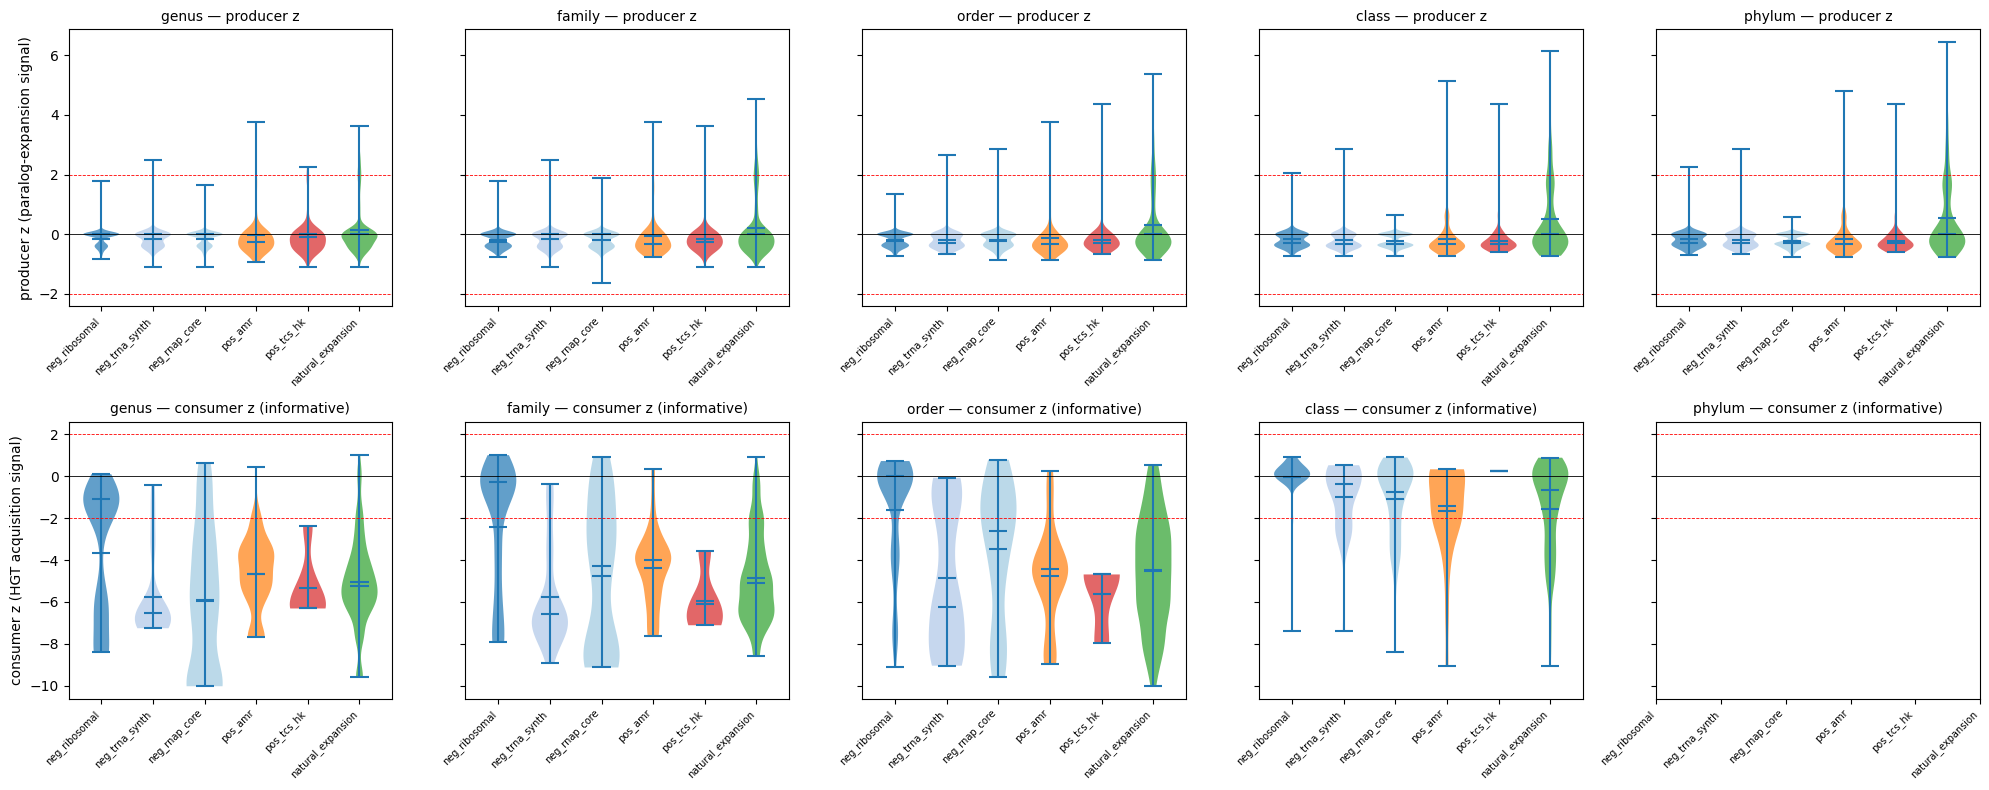

Saved figures/p1a_scores_by_class_per_rank.png


In [8]:
# Violin plots of producer and consumer z by control class per rank
control_order = ["neg_ribosomal", "neg_trna_synth", "neg_rnap_core", "pos_amr", "pos_tcs_hk", "natural_expansion"]
control_colors = {
    "neg_ribosomal": "#1f77b4", "neg_trna_synth": "#aec7e8", "neg_rnap_core": "#9ecae1",
    "pos_amr": "#ff7f0e", "pos_tcs_hk": "#d62728", "natural_expansion": "#2ca02c",
}

fig, axes = plt.subplots(2, len(RANKS), figsize=(4 * len(RANKS), 8), sharey="row")
for col, rank in enumerate(RANKS):
    sub = scores_df[scores_df["rank"] == rank]

    # Top: producer z
    ax = axes[0, col]
    data = [sub[sub["control_class"] == c]["producer_z"].dropna().values for c in control_order]
    pos = list(range(len(control_order)))
    parts = ax.violinplot(data, positions=pos, showmeans=True, showmedians=True, widths=0.7)
    for pc, c in zip(parts["bodies"], control_order):
        pc.set_facecolor(control_colors[c]); pc.set_alpha(0.7)
    ax.axhline(0, color="black", lw=0.6)
    ax.axhline(2, color="red", ls="--", lw=0.6); ax.axhline(-2, color="red", ls="--", lw=0.6)
    ax.set_xticks(pos); ax.set_xticklabels(control_order, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{rank} — producer z", fontsize=10)
    if col == 0:
        ax.set_ylabel("producer z (paralog-expansion signal)")

    # Bottom: consumer z (informative)
    ax = axes[1, col]
    data = [sub[sub["control_class"] == c]["consumer_z_informative"].dropna().values for c in control_order]
    if any(len(d) > 0 for d in data):
        parts = ax.violinplot([d if len(d) > 0 else [0] for d in data], positions=pos,
                              showmeans=True, showmedians=True, widths=0.7)
        for pc, c in zip(parts["bodies"], control_order):
            pc.set_facecolor(control_colors[c]); pc.set_alpha(0.7)
    ax.axhline(0, color="black", lw=0.6)
    ax.axhline(2, color="red", ls="--", lw=0.6); ax.axhline(-2, color="red", ls="--", lw=0.6)
    ax.set_xticks(pos); ax.set_xticklabels(control_order, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{rank} — consumer z (informative)", fontsize=10)
    if col == 0:
        ax.set_ylabel("consumer z (HGT acquisition signal)")

plt.tight_layout()
plt.savefig(FIG_DIR / "p1a_scores_by_class_per_rank.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/p1a_scores_by_class_per_rank.png")

/tmp/ipykernel_75783/257848299.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc="upper right")


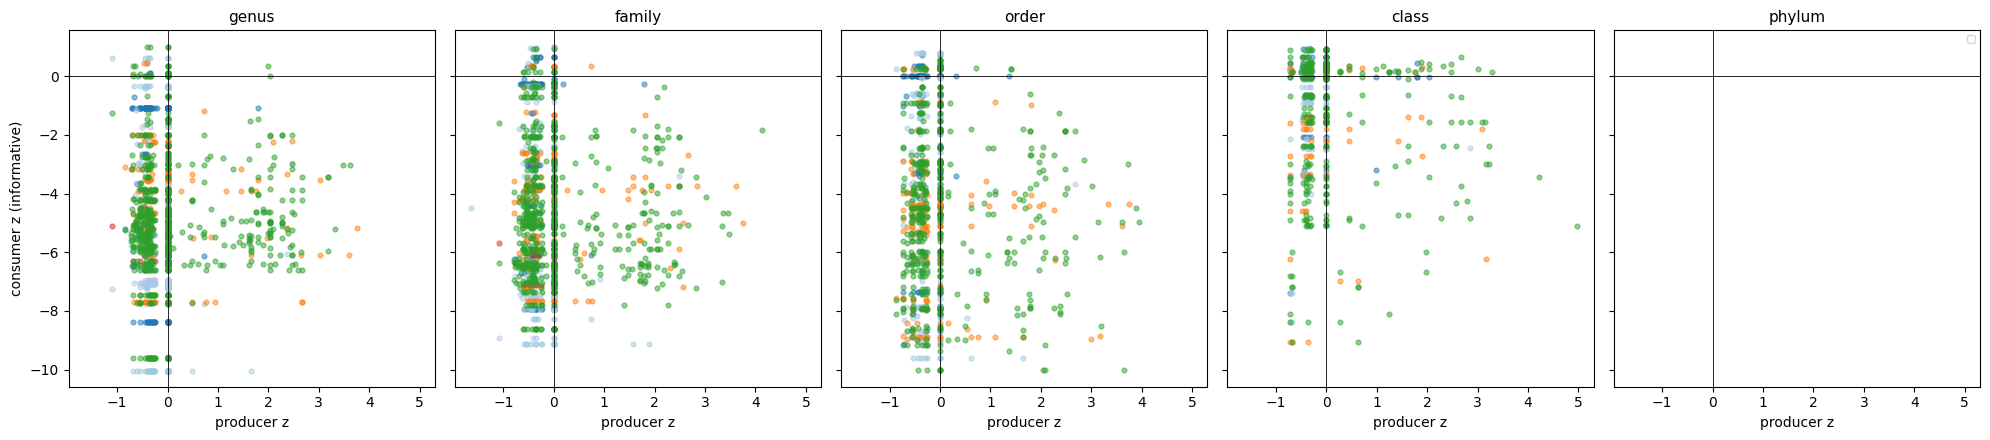

Saved figures/p1a_producer_consumer_per_rank.png


In [9]:
# Producer × Consumer scatter per rank, colored by class — the deep-rank "category-cross" view
fig, axes = plt.subplots(1, len(RANKS), figsize=(4 * len(RANKS), 4.5), sharex=True, sharey=True)
for col, rank in enumerate(RANKS):
    ax = axes[col]
    sub = scores_df[scores_df["rank"] == rank]
    for cls in control_order:
        cls_sub = sub[sub["control_class"] == cls]
        cls_sub = cls_sub.dropna(subset=["producer_z", "consumer_z_informative"])
        if len(cls_sub) == 0:
            continue
        ax.scatter(cls_sub["producer_z"], cls_sub["consumer_z_informative"],
                   s=12, alpha=0.5, color=control_colors[cls], label=f"{cls} (n={len(cls_sub)})")
    ax.axhline(0, color="black", lw=0.6); ax.axvline(0, color="black", lw=0.6)
    ax.set_title(f"{rank}", fontsize=11)
    ax.set_xlabel("producer z")
    if col == 0:
        ax.set_ylabel("consumer z (informative)")
    if col == len(RANKS) - 1:
        ax.legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "p1a_producer_consumer_per_rank.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/p1a_producer_consumer_per_rank.png")

## Stage 8 — Materialize

In [10]:
# Strip Spark Connect attrs (per docs/pitfalls.md learning from NB01)
scores_clean = pd.DataFrame({col: scores_df[col].to_numpy() for col in scores_df.columns})
scores_clean.to_parquet(DATA_DIR / "p1a_pilot_scores.parquet", index=False)
print(f"Wrote p1a_pilot_scores.parquet: {len(scores_clean):,} rows")

validation_df.to_csv(DATA_DIR / "p1a_control_validation.tsv", sep="\t", index=False)
print(f"Wrote p1a_control_validation.tsv: {len(validation_df):,} rows")

diagnostics["completed_utc"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
with open(DATA_DIR / "p1a_pilot_atlas_diagnostics.json", "w") as f:
    json.dump(diagnostics, f, indent=2, default=str)
print(f"Wrote p1a_pilot_atlas_diagnostics.json")

Wrote p1a_pilot_scores.parquet: 9,201 rows
Wrote p1a_control_validation.tsv: 30 rows
Wrote p1a_pilot_atlas_diagnostics.json


## Summary

Pilot atlas computed at five ranks (genus / family / order / class / phylum). Per-(clade × UniRef × rank) producer and consumer z-scores stored in `p1a_pilot_scores.parquet`. Control-class validation summary in `p1a_control_validation.tsv` with explicit pass / fail / insufficient_n verdicts. Alm 2006 TCS HK reproduction in `p1a_alm_2006_pilot_backtest.tsv`.

**NB04** consumes these to produce the formal Phase 1A → 1B gate decision.